In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784' , version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X ,y = mnist["data"] , mnist["target"]

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


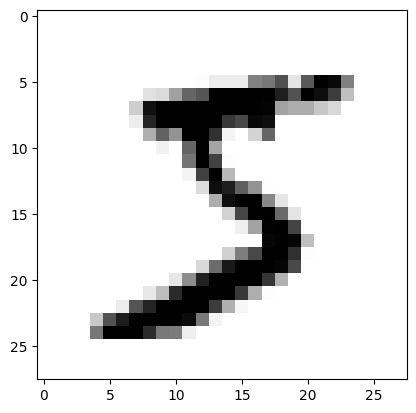

In [10]:
import matplotlib as mal 
import matplotlib.pyplot as plt 
import numpy as np

digit = X.to_numpy()[0]
reshaped_digit = digit.reshape(28 , 28)
plt.imshow(reshaped_digit , cmap = "binary")
plt.show()


In [7]:
y[0]

'5'

In [11]:
y = y.astype(np.uint8)

In [12]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [13]:
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)

In [19]:
from sklearn.linear_model import SGDClassifier

SGD_model = SGDClassifier(random_state=42)
SGD_model.fit(X_train , y_train_5)


,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [20]:
SGD_model.predict([digit])

c:\Users\ELGRM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42 ,shuffle=True)
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(SGD_model)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9669
0.91625
0.96785


In [22]:
from sklearn.model_selection import cross_val_score
cross_val_score(SGD_model, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [27]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(SGD_model, X_train, y_train_5, cv=3)


In [28]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5 , y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [30]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_5, y_train_pred))

print(recall_score(y_train_5, y_train_pred) )

0.8370879772350012
0.6511713705958311


In [31]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [ ]:
y_scores = cross_val_predict(SGD_model, X_train, y_train_5, cv=3,
        method="decision_function")

In [39]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

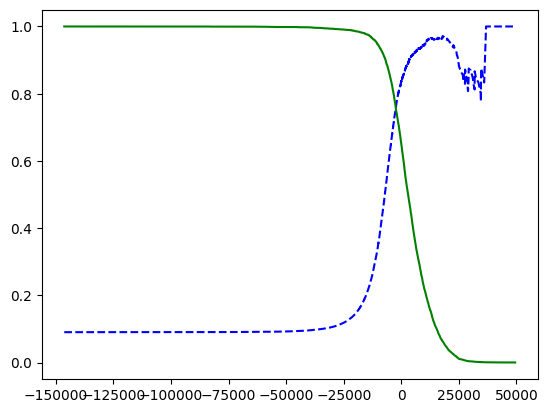

In [40]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [41]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

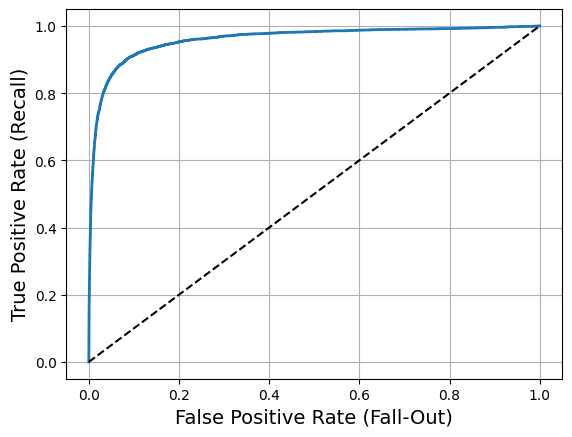

In [44]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=14)
    plt.ylabel('True Positive Rate (Recall)', fontsize=14)
    plt.grid(True)
plot_roc_curve(fpr , tpr)
plt.show()

In [45]:
from sklearn.svm import SVC 
svm_model = SVC()
svm_model.fit(X_train , y_train)
svm_model.predict([digit])

c:\Users\ELGRM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [46]:
some_digit_scores = svm_model.decision_function([digit])
some_digit_scores

c:\Users\ELGRM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [47]:
cross_val_score(svm_model, X_train, y_train, cv=3, scoring="accuracy")

array([0.977 , 0.9738, 0.9739])

In [48]:
from sklearn.linear_model import SGDClassifier

SGD_model.fit(X_train , y_train)
SGD_model.predict([digit])

c:\Users\ELGRM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(SGD_model, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

In [50]:
from sklearn.neighbors import KNeighborsClassifier

Knn_model = KNeighborsClassifier()
Knn_model.fit(X_train , y_train)
knn_accuracy = Knn_model.score(X_test , y_test)
knn_accuracy


0.9688

In [51]:
from sklearn.model_selection import GridSearchCV

Params = [{
    'weights':["uniform", "distance"],
    'n_neighbors': [3,4,5,6]
}]

search = GridSearchCV(Knn_model , Params , cv=5)
search.fit(X_train[:10_000], y_train[:10_000])

,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': [3, 4, ...], 'weights': ['uniform', 'distance']}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,4


In [52]:
search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [53]:
search.best_score_

np.float64(0.9441999999999998)

In [54]:
search.best_estimator_.fit(X_train, y_train)
tuned_accuracy = search.score(X_test, y_test)
tuned_accuracy

0.9714

In [55]:
from scipy.ndimage import shift


In [63]:
def shift_image(image , dx , dy):
    image = image.reshape((28 ,28))
    shifted_image = shift(image , [dy ,dx] , cval= 0 , mode='constant')
    return shifted_image.reshape([-1])


In [66]:
image = X_train.to_numpy()[1000]  # some random digit to demo
shifted_image_down = shift_image(image, 0, 5)
shifted_image_left = shift_image(image, -5, 0)

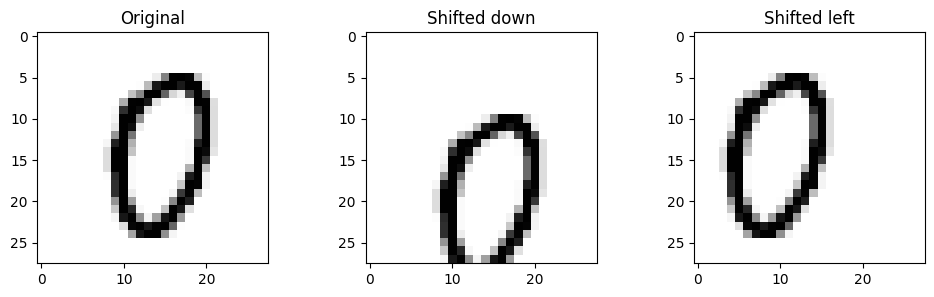

In [67]:
plt.figure(figsize=(12, 3))
plt.subplot(131)
plt.title("Original")
plt.imshow(image.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.subplot(132)
plt.title("Shifted down")
plt.imshow(shifted_image_down.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.subplot(133)
plt.title("Shifted left")
plt.imshow(shifted_image_left.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.show()

In [75]:
X_train = X_train.to_numpy()

X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx , dy in ((-1, 0), (1, 0), (0, 1), (0, -1)):
    for img , label in zip(X_train , y_train):
        X_train_augmented.append(shift_image(img, dx ,dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [76]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [79]:
knn_clf = KNeighborsClassifier(**search.best_params_)

In [80]:
knn_clf.fit(X_train_augmented, y_train_augmented)

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None
